<a href="https://colab.research.google.com/github/henriquecrispim/google-trends-investor-sentiment/blob/main/analise_sentimento_trends.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

/usr/local/lib/python3.12/dist-packages/pytrends/request.py:260: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.fillna(False)
/tmp/ipykernel_1614/2112814279.py:25: FutureWarning: YF.download() has changed argument auto_adjust default to True
  ibov = yf.download("^BVSP", start="2023-01-01", end="2026-06-30")['Close']
[*********************100%***********************]  1 of 1 completed


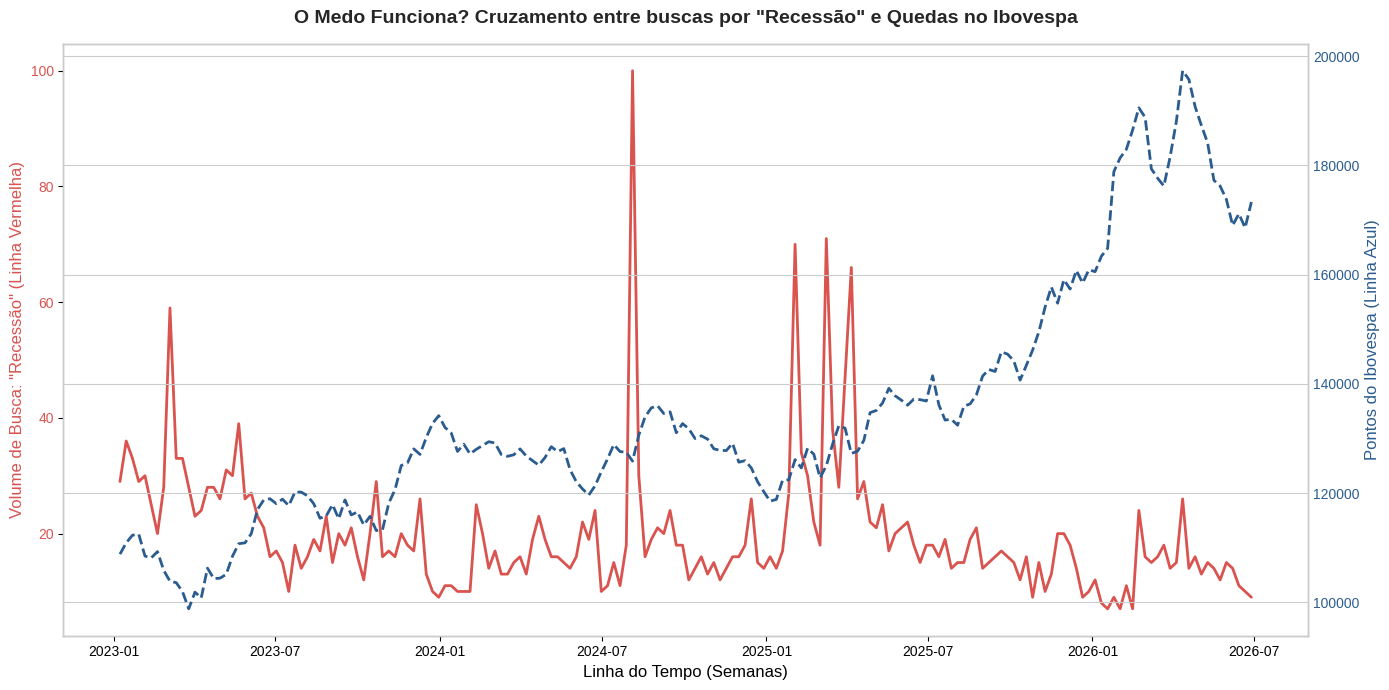

In [2]:
# ==============================================================================
# O IMPACTO DA ATENÇÃO DO INVESTIDOR NO IBOVESPA
# ==============================================================================

!pip install pytrends yfinance matplotlib pandas --quiet

import pandas as pd
import matplotlib.pyplot as plt
from pytrends.request import TrendReq
import yfinance as yf
from datetime import datetime

# 1. Buscar dados do Google Trends (Sentimento de Medo)
pytrends = TrendReq(hl='pt-BR', tz=180)
kw_list = ["Recessão"]
periodo = '2023-01-01 2026-06-30'

pytrends.build_payload(kw_list, cat=0, timeframe=periodo, geo='BR')
df_trends = pytrends.interest_over_time()

if 'isPartial' in df_trends.columns:
    df_trends = df_trends.drop(columns=['isPartial'])

# 2. Buscar dados REAIS de mercado (Ibovespa)
ibov = yf.download("^BVSP", start="2023-01-01", end="2026-06-30")['Close']
# Alinhar os dados por semana (já que o Trends histórico é semanal)
ibov_semanal = ibov.resample('W').last()

# Juntar os dois dados na mesma tabela pelo histórico de datas
df_analise = df_trends.join(ibov_semanal, how='inner')
df_analise.columns = ['Buscas_Recessao', 'Ibovespa']

# 3. Construir o gráfico com DOIS EIXOS (Agora faz sentido!)
fig, ax1 = plt.subplots(figsize=(14, 7))
plt.style.use('seaborn-v0_8-whitegrid')

# Eixo 1 (Esquerda): O Medo do Público (Google Trends)
color = '#d9534f' # Vermelho para alerta
ax1.set_xlabel('Linha do Tempo (Semanas)', fontsize=12)
ax1.set_ylabel('Volume de Busca: "Recessão" (Linha Vermelha)', color=color, fontsize=12)
ax1.plot(df_analise.index, df_analise['Buscas_Recessao'], color=color, linewidth=2, label='Busca por Recessão')
ax1.tick_params(axis='y', labelcolor=color)

# Eixo 2 (Direita): O Mercado Financeiro Real (Ibovespa)
ax2 = ax1.twinx()  # Cria o segundo eixo que compartilha o mesmo eixo X de datas
color = '#2b5c8f' # Azul para o mercado financeiro
ax2.set_ylabel('Pontos do Ibovespa (Linha Azul)', color=color, fontsize=12)
ax2.plot(df_analise.index, df_analise['Ibovespa'], color=color, linewidth=2, linestyle='--', label='Ibovespa (Pontos)')
ax2.tick_params(axis='y', labelcolor=color)

# Título explicativo do que está acontecendo
plt.title('O Medo Funciona? Cruzamento entre buscas por "Recessão" e Quedas no Ibovespa', fontsize=14, fontweight='bold', pad=15)
fig.tight_layout()

# Salvar o gráfico 
plt.savefig('analise_sentimento.png', dpi=300)
plt.show()